# Transfer Matrix Method and Multilayer Dielectric Structues

## 1. Connection with previous content

In the previous implementation we studied multiple-beam, interference in one thin film and derived an analytical expression for the total reflection coefficient.

That model successfully described Fabry-Pérot resonances, free spectral range (FSR) and finesse for a single layer.

However,most real optical devices consist of multiple dielectric layers. Deriving closed-form expression for several layers is impractical.

In this implementation, we generalize the interference model using the Transfer Matrix Method (TMM), which allows us to compute reflection and transmission for an arbitrary number of layers.

This formalism is a systematic expansion of the thin-film model studied previously.

## 2. Phisycal Model

We consider a monochromatic plane wave of wavelength $\lambda$ incident normally on a stratified structure composed of $N$ layers:

$ n_0\hspace{0.5cm}|\hspace{0.5cm} n_1 \hspace{0.5cm}|\hspace{0.5cm} n_2 \hspace{0.5cm}| \hspace{0.5cm}···\hspace{0.5cm} | \hspace{0.5cm}n_N\hspace{0.5cm} | \hspace{0.5cm}n_s $

Each layer i has:

- refractive index $n_i$
- thickness $d_i$

The goal is to compute the total reflection coefficient of the entire stack.

## 3. Field Representation

Inside each homogeneus layer, the electric field satisfy the wave equation. The general solurion is:

$E_i(z) = A_i e^{ik_iz} + B_i e^{-ik_i z} $

where:

$k_i = \dfrac{2\pi n_i}{\lambda} $

$A_i$ and $B_i$ represent forward and backward propagating waves.

This is the same physical description used in the previous implementation, now extended to mulltiple lyers.

## 4. Boundary conditions

At each interface, Maxwell's conditions impose:

- Continuity of the tangencial electric field
- Continuity of the tangencial magnetic field

For normal incidence, these conditions relate field amplitudes between adjacent layers.

## 5. Transfer Matix of a Single Layer

The effect of propagation through a single layer can be written in matrix form:

$M_i=$ $\begin{pmatrix}
\cos(\delta_i) & (i/q_i)sin(\delta_i)\\
i q_i \sin(\delta_i) & \cos(\delta_i)
\end{pmatrix}$

where:

$\delta_i = \dfrac{2 \pi n_i d_i}{\lambda} $

For normal incidence:

$q_i = n_i $

Here $q_i$ represents the **Optical admittance** of the medium. Physically the admitance connects the electric and magnetic field amplitudes ($H =q E$) We are explicity setting $q_i = n_i $ assuming **normal incidence**. For oblique incidence the admittance would split into $q_i = n_i \cos(\theta_i)$ for TE polarization and $q_i = n_i \cos(\theta_i)$ for Tm polarization. Keeping normal incidence ensures polarization degeneracy.

This matrix contains both phase accumulation and impedance effets.

## 6. Total Transfer Matrix

For N layers, the total system matrix is:

$ M = M_1\hspace{0.5cm}M_2\hspace{0.5cm}···\hspace{0.5cm}M_N $

Matrix multiplication automatically includes:

- All internal reflactions
- All phase accumulation
- All multiple-beam interference

For $N=1$, this formalism produces the thin-film result derived in the previous study.

## 7. Reflection and Transmission Coefficients

### 7.1 Generalized Reflection Coefficient

If $q_0$ is the optical admittance of the incident medium and $q_s$ that of the substrate, the generalized reflection coefficient from the system's admittance $Y = C/B$) is: 

$r=\dfrac{q_0 M_{11} + q_0 M_{12} q_s - M_{21} -  M_{22} q_s}{q_0 M_{11} + q_0 M_{12} q_s + M_{21} + M_{22} q_s} $

Reflectance:

$ R = |r|^2$

The formula is valid for any number of layers.

### 7.2 Transmission Coefficient

From the total Matrix M of the structure:

$M=$ $\begin{pmatrix}
M_{11} & M_{12}\\
M_{21} & M_{22}
\end{pmatrix}$

The transmission coefficient at normal incidence is:

$r=\dfrac{2n_0}{n_0 M_{11} + n_0 M_{12} n_s + M_{21} + M_{22} n_s} $

This expression follows from applying Maxwell boundary conditions at the first and last interface of the multilayer system.

### 7.3 Transmittance and Energy Conservation

The transmittance is not simply $|t|^2$.

Because energy flux depends on the refractive index, the correct expression is:

$ T =\dfrac{n_s}{n_0} |r|^2$

The prefactor $n_s/n_0$ accounts for the ratio of optical admittances between the substrate and incidence medium. This ensures correct power normalization.

For lossless dielectric stack:

$R + T = 1$

This condition provides a stron numerical validation of the implementation.

If:

$max | R + T - 1 | << 1 $

then the transfer matrix method algorithm is correctly implemented and no artificial numerical losses are present. The numercial verification of $R + T = 1$ confirms that the multilayer system conserves electromagnetic energy, as expected for non-absorbing dielectric materials.

## 8. Bragg Mirror (Quarter-Wave Stack)

A Bragg mirror consists of alterning high and low index layers:

$ n_H\hspace{0.5cm}|\hspace{0.5cm} n_L \hspace{0.5cm}|\hspace{0.5cm} n_H \hspace{0.5cm} | \hspace{0.5cm}n_L\hspace{0.5cm} | \hspace{0.5cm} ···$

Each layer is designed as:

$ d =\dfrac{\lambda_0}{4n} $

**Physical meaning of the $\lambda/4$ :** A thickness of the quarter-wavelength guarantees that the phase wave accumulates exactly a $\pi /2$ phase shift during a single pass through the layer (or $\pi$ for a round trip). 

When light reflects off a boundary going from low-index to high-index medium, it undergoes an additional $\pi$ phase shift. The combinations of these structural and boundary phase shifts results in perfectly constructive interference for all reflected partial waves at the desing wavelength $\lambda_0$.

Increasing:

- Number of pairs $\rightarrow$ increases reflectivity
- Index contrast $\rightarrow$ increases bandwidth

This structure is the one-dimensional analogue of the photonic crystal.

### 8.1 Analytical Estimation of the Bragg Mirror Stop Band

For a quarter-wave stack composed of alterning refractive indices $n_H$ and $n_L$, an approximate analytical expression for the stop band width is given by:

$\Delta\lambda = \dfrac{4\lambda_0}{\pi}\arcsin\left(\dfrac{n_H - n_L}{n_H + n_L}\right) $

This result is given under the assumption of:

- Infinite periodic structure
- Normal incidence
- Quarter-wave desing condition

It provides an estimate of the width of the high reflecticity region centered at $\lambda_0$.

## 9. Theoretical References

Conceptual background:

Hecht, *Optics*

Formal development of layered media:

Born & Wolf , *Principles of Optics*

Multilayer and photonic structures:

Yeh, *Optical Waves in Layered Media*

## Definition of functions

We define the matrix of a single thin film, the matrix of the set of layers, and the total reflection and transmission coefficients.

And a function for studying energy conservation based on the calculation of transmittance and reflectance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
folder_path = "../figures/week 4"
os.makedirs(folder_path, exist_ok=True)

In [2]:
def layer_matrix(n, d, wavelength):
    delta = 2 * np.pi * n * d / wavelength
    q = n

    M11 = np.cos(delta) 
    M12 = 1j * np.sin(delta) / q
    M21 = 1j * q * np.sin(delta)
    M22 = np.cos(delta)

    return np.array([[M11, M12],
                     [M21, M22]])

In [3]:
def total_matrix(n_layers, d_layers, wavelength):
    M = np.identity(2, dtype=complex)

    for n,d in zip(n_layers, d_layers):
        M = M @ layer_matrix(n, d, wavelength) 

    return M

In [4]:
def reflection_coefficient(n0, ns, n_layers, d_layers, wavelength):
    M = total_matrix(n_layers, d_layers, wavelength)

    q0 = n0
    qs = ns

    numerator = q0*M[0,0] + q0*M[0,1]*qs - M[1,0] - M[1,1]*qs
    denominator = q0*M[0,0] + q0*M[0,1]*qs + M[1,0] + M[1,1]*qs

    return numerator/denominator

In [5]:
def reflection_transmission(n0, ns, n_layers, d_layers, wavelength):

    q0 = n0
    qs = ns

    M = total_matrix(n_layers, d_layers, wavelength)

    M11, M12 = M[0,0] , M[0,1]
    M21, M22 = M[1,0] , M[1,1]

    denominator = q0*M11 + q0*M12*qs + M21 + M22*qs

    r =  (q0*M11 + q0*M12*qs - M21 - M22*qs) / denominator
    t = (2*q0) / denominator

    R = np.abs(r)**2
    T = (qs/q0) * np.abs(t)**2

    return R, T

## Physical parameters

### Single Layer Validation

The first simulation aims to validate the matrix transfer method for a single layer of glass.
The selected wavelength range corresponds mainly to the visible spectrum.

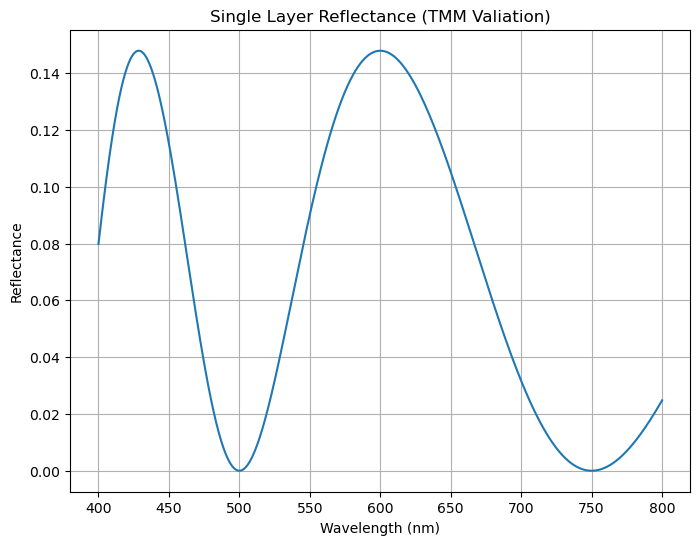

In [6]:
n0 = 1.0
ns = 1.0

n_layers = [1.5]
d_layers = [500e-9]

wavelength = np.linspace(400e-9, 800e-9, 2000)

R = []

for wl in wavelength:
    r= reflection_coefficient(n0, ns, n_layers, d_layers, wl)
    R.append(np.abs(r)**2)

R = np.array(R)

plt.figure(figsize=(8,6))
plt.plot(wavelength*1e9,R)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Single Layer Reflectance (TMM Valiation)")
plt.savefig(f"{folder_path}/Single Layer Reflectance (TMM Valiation).png", dpi=300)
plt.grid()
plt.show()

The result indicates a clear similarity in reflectance behavior obtained with the study previously conducted in week 3.

### Arbitary Multilayer

We implemented an arbitrary set of layers with different refracction index and thicknesses for the layers.

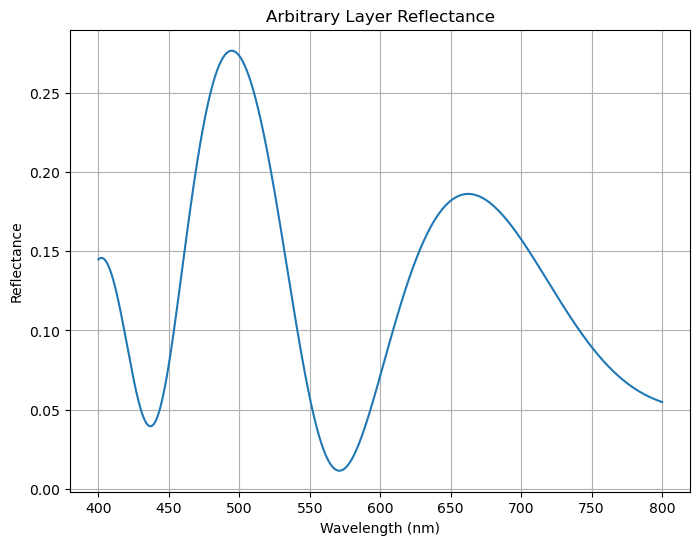

In [7]:
n_layers = [1.5, 2.0, 1.4]
d_layers = [200e-9, 300e-9, 150e-9]

R_multi = []
T_multi = []

for wl in wavelength:
    r = reflection_coefficient(n0, ns, n_layers, d_layers, wl)
    R_multi.append(np.abs(r)**2)

R_multi = np.array(R_multi)

plt.figure(figsize=(8,6))
plt.plot(wavelength*1e9,R_multi)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Arbitrary Layer Reflectance")
plt.savefig(f"{folder_path}/Arbitrary Layer Reflectance.png", dpi=300)
plt.grid()
plt.show()

The reflectance spectrum shows much more complex behavior than in the case of a single layer that follows harmonic behavior.

In [106]:
R_list = []
T_list = []

for wl in wavelength:
    R_val, T_val = reflection_transmission(n0, ns, n_layers, d_layers, wl)
    R_list.append(R_val)
    T_list.append(T_val)

R_array = np.array(R_list)
T_array = np.array(T_list)

# Check Energy Conservation
print("Max deviation:", np.max(np.abs(R_array + T_array - 1)))

Max deviation: 8.881784197001252e-16


We can assume that energy conservation holds true for the arbitrary multilayer system, since the maximum deviation is much smaller than one.

### Bragg Mirror

The refractive indices are exchanged for each layer from a high value to a lower one an even number of times. The thickness is defined by the analytical expression explained above.

In our study, we determined:

- $n_H = 2.2 $
- $n_L = 1.45 $
- $\lambda_0 = 600\hspace{0.1cm}nm$

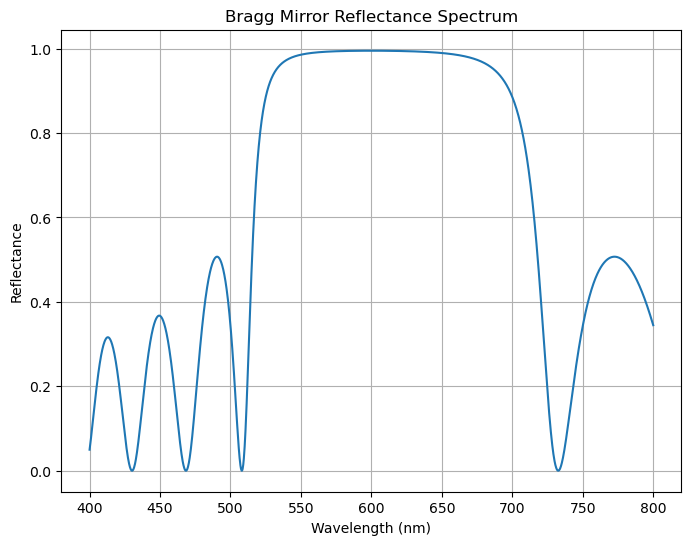

In [8]:
nH = 2.2
nL = 1.45

lambda0 = 600e-9

dH = lambda0 / (4*nH)
dL = lambda0 / (4*nL)

pairs = 8

n_layers = []
d_layers = []

for i in range(pairs):
    n_layers.append(nH)
    d_layers.append(dH)
    n_layers.append(nL)
    d_layers.append(dL)


R_bragg = []

for wl in wavelength:
    r = reflection_coefficient(n0, ns, n_layers, d_layers, wl)
    R_bragg.append(np.abs(r)**2)

R_bragg = np.array(R_bragg)

plt.figure(figsize=(8,6))
plt.plot(wavelength*1e9,R_bragg)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Bragg Mirror Reflectance Spectrum")
plt.savefig(f"{folder_path}/Bragg Mirror Reflectance Spectrum.png", dpi=300)
plt.grid()
plt.show()

As expected, the result shows a region of high reflectivity centered around $\lambda_0$.

Next, we proceed to study the dependence of the number of pairs and the index contrast for the Bragg mirror. In addition to calculating the stop band bandwidth analytically and numerically.

In [108]:
# ---- Stop bandwidth stimation ---

# We define a high reflectivity threshold

threshold = 0.9

# We find regions where reflectivity > threshold

high_R_indices = np.where(R_bragg>threshold)[0]

if len(high_R_indices) > 0:
    lambda_min = wavelength[high_R_indices[0]]
    lambda_max = wavelength[high_R_indices[-1]]

    bandwidth = lambda_max - lambda_min

    print("Stop bandwidth (nm) = ", bandwidth * 1e9)
    print("Stop band form (nm) :", lambda_min * 1e9, "to", lambda_max * 1e9)

else: 

    print("No Stop band above threshold detected")

Stop bandwidth (nm) =  171.68584292146065
Stop band form (nm) : 526.2631315657829 to 697.9489744872435


In [109]:
# Analytical validation of Bragg Mirror Stop Band
lambda_0 = 600e-9
n_H = 2.2
n_L = 1.45

# Analytical formula for the fractional bandwidth
delta_lambda_analytical = (4 * lambda_0 / np.pi) * np.arcsin((n_H - n_L) / (n_H + n_L))

print(f"Theoretical Stop Band Width (approx): {delta_lambda_analytical * 1e9:.2f} nm")
# You can then visually compare this value with the FWHM of the plateau in your Bragg mirror plot!

Theoretical Stop Band Width (approx): 158.10 nm


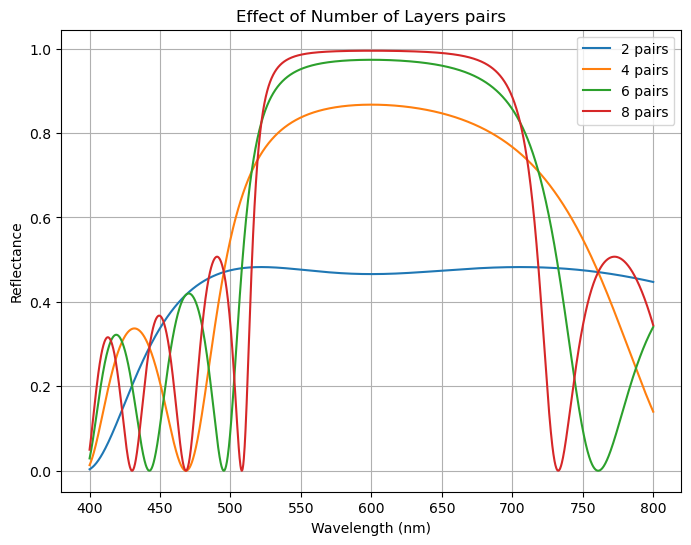

In [9]:
### pair number dependence

pairs_list = [2, 4, 6, 8]

plt.figure(figsize=(8,6))

for pairs in pairs_list:

    n_layers = []
    d_layers = []

    for i in range(pairs):
        n_layers.append(nH)
        d_layers.append(dH)
        n_layers.append(nL)
        d_layers.append(dL)


    R_temp = []

    for wl in wavelength:
        r = reflection_coefficient(n0, ns, n_layers, d_layers, wl)
        R_temp.append(np.abs(r)**2)

    R_temp = np.array(R_temp)

    plt.plot(wavelength*1e9, R_temp, label=f"{pairs} pairs")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Effect of Number of Layers pairs")
plt.savefig(f"{folder_path}/Effect of Number of Layers pairs.png", dpi=300)
plt.grid()
plt.legend()
plt.show()

We observe a clear relationship with the number of even layers; reflectivity is proportional to the number of pairs of layers selected. As the number of pairs increases, the bandwidth is well defined; for low numbers, it shows edges with an abrupt configuration.

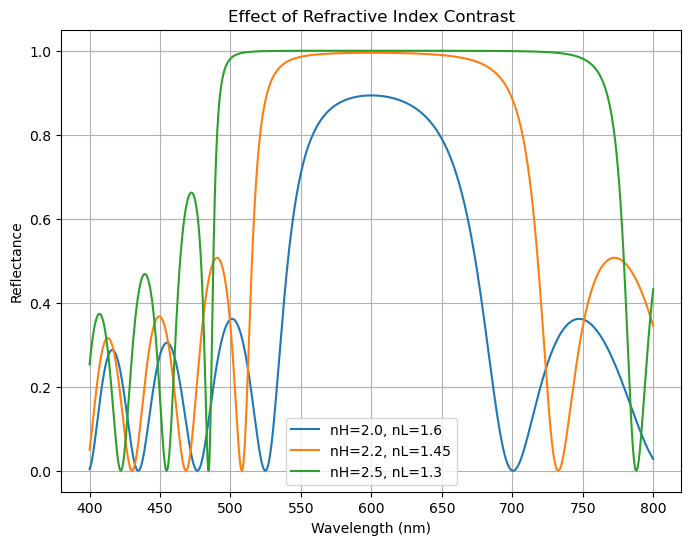

In [10]:
### contrast index dependence

contrast_cases = [(2.0, 1.6), (2.2, 1.45), (2.5, 1.3)]

plt.figure(figsize = (8,6))

for nH_var, nL_var in contrast_cases:

    dH_var = lambda0 / (4*nH_var)
    dL_var = lambda0 / (4*nL_var)

    pairs = 8

    n_layers = []
    d_layers = []

    for i in range(pairs):
        n_layers.append(nH_var)
        d_layers.append(dH_var)
        n_layers.append(nL_var)
        d_layers.append(dL_var)

    R_cont = []


    for wl in wavelength:
        r = reflection_coefficient(n0, ns, n_layers, d_layers, wl)
        R_cont.append(np.abs(r)**2)

    R_cont = np.array(R_cont)


    plt.plot(wavelength*1e9, R_cont, label=f"nH={nH_var}, nL={nL_var}")

    
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Effect of Refractive Index Contrast")
plt.savefig(f"{folder_path}/Effect of Refractive Index Contrast.png", dpi=300)
plt.grid()
plt.legend()
plt.show()

An increase in contrast in the indices shows an increase in the reflectivity of the layer system and a wider band.

## Discussion and Results

The Transfer Matrix Method successfully generalizes the thin-film model studied in Week 3 to arbitrary multilayer structures.

The first simulation confirms that TMM reproduces exactly the Fabry-Pérot resonances obtained previously, validating the numerical implementation.

For arbitrary multilayer stacks, the reflectance spectrum becomes increasingly structured due to coherent interferences among multiple interfaces. The spectral response is no longer a simple periodic function but reflects the cumulative phase and the impedance mismatches across all layers.

The conservation of energy condition was used as a stringent validation test of the implementation. A deviation from unity would indicate inconsistencies in the characteristic matrix formulation or in the normalization of the transmission coefficient. After correcting the characteristic matrix definition, the numerical deviation was reduced to machine precision, confirming the internal consistency of the model.

The Bragg Mirror reveals the emergence of a photonic stop band, a wavelength region of high reflectivity centered at the desing wavelength $\lambda_0$. This high reflectivity region arises from constructive interference of reflections at each interface under the quarter-wave condition.

Increasing the number of layers pairs enhances the reflectance inside the stop band and sharpens its edges, indicating stringer coherent builup.

Increasing the refractive index contrast broadens the stop band, demonstrating that the stop bandwidth is directly related to impedance mismatch.

The comparison between the analytical stop-band estimate and the numerical spectrum confirms that the multilayer behaves as a one-dimensional photonic crystal. The agreement validates both the phase accumulation model and the interference mechanism responsible for the photonic band gap formation.


## Conlusions 

The Transfer Matrix Method provides a powerful and systematic framework for modeling electromagnetic wave propagation in stratified dielectric media.

This method extedns the single thin-film interference model to arbitraty multilayer systems without requiring complex analytical derivations.

The simulations demonstrate:

- Accurate reproduction of single-layer Fabry-Pérot behavior.
- Complex spectral shaping of arbitrary multilayer stacks.
- Emergence of a photonic stop band in periodic quarter-wave structures.

The Bragg Mirror example illustrates how interference engineering can be used to desing high-reflectivity optical components.

These results connects Maxwell's boundary conditions with pratical optical device desing and form the theorical bases of dielectric mirrors, interference filters, and one-dimensional photonic crystals.

The explicit verification of energy conservation and the analytical comparison of the Bragg stop band significantly strengthen the physical credibility of the numerical implementation.

The project demonstrates how computational modeling enables the exploration and desing of advanced optical structures beyond analytical limitations.